## Setup and Library Installation

In [1]:
# Install necessary libraries
!pip install transformers[torch] datasets scikit-learn matplotlib seaborn

## Load IMDB Dataset (Kaggle Sourcing)

In [2]:
import kagglehub
import os
import pandas as pd
import torch

# Set device globally
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Download dataset from Kaggle
path = kagglehub.dataset_download('vishakhdapat/imdb-movie-reviews')
print('Data downloaded to:', path)

# 2. Identify and Load the CSV file
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
df_raw = pd.read_csv(os.path.join(path, csv_file))

print(f"\nRaw Data Loaded. Shape: {df_raw.shape}")
df_raw.head()

100%|██████████| 25.7M/25.7M [00:00<00:00, 80.7MB/s]

Extracting files...


Data downloaded to: /root/.cache/kagglehub/datasets/vishakhdapat/imdb-movie-reviews/versions/1

Raw Data Loaded. Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Data Preprocessing & Splitting

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# 1. Standardize and Clean
df_prep = df_raw.copy()
df_prep.columns = df_prep.columns.str.lower().str.strip()
df_prep['label'] = df_prep['sentiment'].str.lower().str.strip().map({'positive': 1, 'negative': 0})
df_prep['text'] = df_prep['review'].str.replace('<br />', ' ')
df_prep = df_prep[['text', 'label']].dropna().reset_index(drop=True)

# 2. Create Subset (350 Train, 75 Val, 75 Test)
df_subset = df_prep.sample(500, random_state=42)
train_df, temp_df = train_test_split(df_subset, train_size=350, random_state=42, stratify=df_subset['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Split complete: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

Split complete: Train=350, Val=75, Test=75


## Tokenization & Dataset Class

In [ ]:
from torch.utils.data import Dataset
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, padding="max_length", truncation=True, max_length=128)
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Create Dataset objects
train_dataset = IMDBDataset(train_df['text'].tolist(), train_df['label'].tolist())
val_dataset = IMDBDataset(val_df['text'].tolist(), val_df['label'].tolist())
test_dataset = IMDBDataset(test_df['text'].tolist(), test_df['label'].tolist())

## Model & Evaluation Helper Functions

In [7]:
import numpy as np
from transformers import BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

def run_bert_experiment(model_name, train_ds, val_ds, unfreeze_last_2=False):
    # Load model and move to device
    model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to(device)

    # Logic for unfreezing specific layers
    if unfreeze_last_2:
        for param in model.bert.parameters():
            param.requires_grad = False
        # Unfreeze the last two encoder layers (10 and 11)
        for i in range(10, 12):
            for param in model.bert.encoder.layer[i].parameters():
                param.requires_grad = True

    # Updated TrainingArguments with the correct keyword: eval_strategy
    args = TrainingArguments(
        output_dir=f'./{model_name}',
        num_train_epochs=5,
        per_device_train_batch_size=5,
        learning_rate=2e-5,
        eval_strategy="epoch",  # FIX: Changed from evaluation_strategy
        save_strategy="no",
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics
    )

    trainer.train()
    return trainer

def plot_results(trainer, test_ds, title):
    preds_output = trainer.predict(test_ds)
    preds = np.argmax(preds_output.predictions, axis=1)
    labels = preds_output.label_ids

    # Calculate and Print
    acc = accuracy_score(labels, preds)
    print(f"\n{title} Test Accuracy: {acc:.4f}")

    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'CM: {title}'); plt.show()
    return acc # Return accuracy for the final comparison

## Experiment 1 - Full Fine-Tuning

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.525176,0.760000,0.727273,0.705882,0.750000
2,No log,0.530439,0.760000,0.718750,0.718750,0.718750
3,No log,0.911097,0.773333,0.746269,0.714286,0.781250
4,No log,1.036819,0.773333,0.746269,0.714286,0.781250
5,No log,1.101328,0.760000,0.735294,0.694444,0.781250



Full Fine-Tuning Test Accuracy: 0.8400


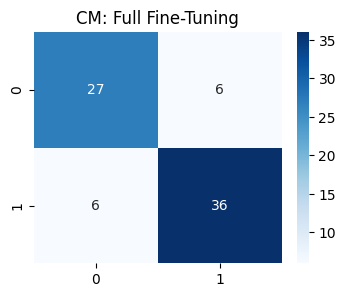

In [8]:
# Train Full Model
trainer_full = run_bert_experiment("Full_Tuning", train_dataset, val_dataset, unfreeze_last_2=False)

# Evaluate and Show Graph
acc_full = plot_results(trainer_full, test_dataset, "Full Fine-Tuning")

## Experiment 2 - Freezing BERT Layers

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.657852,0.640000,0.557377,0.586207,0.531250
2,No log,0.604838,0.720000,0.734177,0.617021,0.906250
3,No log,0.608761,0.693333,0.716049,0.591837,0.906250
4,No log,0.574372,0.760000,0.756757,0.666667,0.875000
5,No log,0.581299,0.760000,0.763158,0.659091,0.906250



Last 2 Layers Test Accuracy: 0.7200


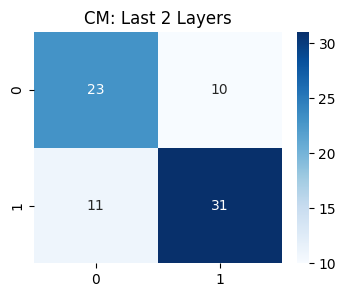

In [9]:
# Train Partial Model (Experiment)
trainer_last2 = run_bert_experiment("Last_2_Layers", train_dataset, val_dataset, unfreeze_last_2=True)

# Evaluate and Show Graph
acc_last2 = plot_results(trainer_last2, test_dataset, "Last 2 Layers")

## Visualizing Performance (Graphs)

/tmp/ipykernel_8236/2259641007.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=methods, y=accuracies, palette='magma')


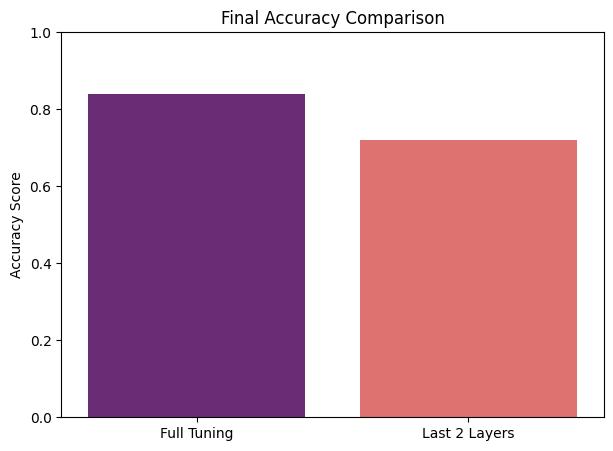

In [10]:
# Final comparison bar chart
methods = ['Full Tuning', 'Last 2 Layers']
accuracies = [acc_full, acc_last2]

plt.figure(figsize=(7, 5))
sns.barplot(x=methods, y=accuracies, palette='magma')
plt.title('Final Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)
plt.show()